In [1]:
import numpy as np
import pandas as pd
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection permutation_test_scoreimport train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Embedding, SpatialDropout1D, concatenate, Dropout
from tensorflow.keras.layers import GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing import text, sequence
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns


## Загрузка данных

In [2]:
def load_data(file_path):
    """
    Загрузка данных из CSV файла
    """
    print(f"Загрузка данных из {file_path}...")
    df = pd.read_csv(file_path)
    
    # Проверка структуры
    print(f"Размер датасета: {df.shape}")
    print(f"Колонки: {df.columns.tolist()}")
    
    # Переименовываем колонки для удобства
    if 'comment' in df.columns and 'toxic' in df.columns:
        df = df.rename(columns={'toxic': 'label'})
    elif 'comment' in df.columns and 'label' in df.columns:
        pass  # уже правильно
    else:
        df.columns = ['comment', 'label'] if len(df.columns) == 2 else df.columns
    
    # Проверка типов
    print(f"\nТипы данных:")
    print(df.dtypes)
    
    print(f"\nСтатистика по меткам:")
    print(df['label'].value_counts())
    print(f"\nСреднее значение метки: {df['label'].mean():.3f}")
    
    return df

In [3]:
load_data("labeled.csv")

Загрузка данных из labeled.csv...
Размер датасета: (14412, 2)
Колонки: ['comment', 'toxic']

Типы данных:
comment     object
label      float64
dtype: object

Статистика по меткам:
label
0.0    9586
1.0    4826
Name: count, dtype: int64

Среднее значение метки: 0.335


,comment,label
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


## Предобработка текста

In [4]:
# Функция предобработки текста
def preprocess_text(text):
    """
    Очистка и предобработка текста
    """
    if not isinstance(text, str):
        text = str(text)
    
    # Замена ё на е
    text = text.replace("ё", "е").replace("Ё", "Е")
    
    # Замена URL
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' URL ', text)
    
    # Удаление лишних символов, оставляем буквы и пробелы
    text = re.sub(r'[^a-zA-Zа-яА-Я\s]', ' ', text)
    
    # Множественные пробелы заменяем на один
    text = re.sub(r'\s+', ' ', text)
    
    # Приводим к нижнему регистру
    text = text.lower().strip()
    
    return text


## Функция распределения классов

In [5]:
def plot_class_distribution(df):
    """
    Построение графиков распределения классов
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Количество комментариев по классам
    class_counts = df['label'].value_counts().sort_index()
    colors = ['#2ecc71', '#e74c3c']
    
    axes[0, 0].bar(['Нетоксичные (0)', 'Токсичные (1)'], class_counts.values, color=colors)
    axes[0, 0].set_title('Распределение классов', fontsize=14)
    axes[0, 0].set_ylabel('Количество комментариев')
    
    # Добавляем значения на столбцы
    for i, v in enumerate(class_counts.values):
        axes[0, 0].text(i, v + 50, str(v), ha='center', fontsize=12)
    
    # 2. Круговая диаграмма
    axes[0, 1].pie(class_counts.values, 
                   labels=['Нетоксичные\n(0)', 'Токсичные\n(1)'], 
                   colors=colors, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Соотношение классов', fontsize=14)
    
    # 3. Распределение длин комментариев
    df['comment_length'] = df['comment'].astype(str).str.len()
    
    axes[1, 0].hist(df[df['label']==0]['comment_length'], bins=50, alpha=0.7, 
                    label='Нетоксичные', color='#2ecc71')
    axes[1, 0].hist(df[df['label']==1]['comment_length'], bins=50, alpha=0.7, 
                    label='Токсичные', color='#e74c3c')
    axes[1, 0].set_title('Распределение длин комментариев', fontsize=14)
    axes[1, 0].set_xlabel('Длина комментария (символы)')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].legend()
    
    # 4. Boxplot длин комментариев
    data_to_plot = [df[df['label']==0]['comment_length'], 
                    df[df['label']==1]['comment_length']]
    
    bp = axes[1, 1].boxplot(data_to_plot, labels=['Нетоксичные', 'Токсичные'], 
                            patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1, 1].set_title('Распределение длин комментариев (Boxplot)', fontsize=14)
    axes[1, 1].set_ylabel('Длина комментария')
    
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return class_counts

## Функция создания модели

In [6]:
def create_model(max_features, maxlen, embedding_matrix=None, embedding_size=300):
  
    inp = Input(shape=(maxlen,))
    
    if embedding_matrix is not None:
        x = Embedding(max_features, embedding_size, 
                      weights=[embedding_matrix], 
                      trainable=False)(inp)
    else:
        x = Embedding(max_features, embedding_size)(inp)
    
    x = SpatialDropout1D(0.3)(x)
    x = Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
    x = Bidirectional(GRU(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
    
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    
    conc = concatenate([avg_pool, max_pool])
    
    conc = Dropout(0.5)(conc)
    conc = Dense(64, activation='relu')(conc)
    conc = Dropout(0.3)(conc)
    
    # Для бинарной классификации
    outp = Dense(1, activation='sigmoid')(conc)
    
    model = Model(inputs=inp, outputs=outp)
    
    # Используем Adam с уменьшением learning rate
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy', 
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


## Основная функция обучения модели

In [7]:

def train_model():
    print("=" * 60)
    print("ЗАПУСК ОБУЧЕНИЯ МОДЕЛИ ДЛЯ КЛАССИФИКАЦИИ КОММЕНТАРИЕВ")
    print("=" * 60)
    
    # Параметры
    MAX_FEATURES = 50000
    MAXLEN = 300
    EMBEDDING_SIZE = 300
    BATCH_SIZE = 64
    EPOCHS = 20
    VALIDATION_SPLIT = 0.2
    
    # Шаг 1: Загрузка данных
    print("\n[1/8] Загрузка данных...")
    try:
        df = load_data('labeled.csv')
        print(f"\nЗагружено {len(df)} комментариев")
    except FileNotFoundError:
        print("Файл dataset.csv не найден!")
        return None, None, None
    
    # Шаг 2: Предобработка текста
    print("\n[2/8] Предобработка текста...")
    df['clean_comment'] = df['comment'].apply(preprocess_text)
    df = df[df['clean_comment'].str.len() > 0]
    print(f"После обработки осталось {len(df)} комментариев")
    
    # Шаг 3: Визуализация распределения
    print("\n[3/8] Визуализация данных...")
    class_dist = plot_class_distribution(df)
    
    # Шаг 4: Разделение на train/test
    print("\n[4/8] Разделение на обучающую и тестовую выборки...")
    X = df['clean_comment'].values
    y = df['label'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Размер обучающей выборки: {len(X_train)}")
    print(f"Размер тестовой выборки: {len(X_test)}")
    
    # Шаг 5: Токенизация
    print("\n[5/8] Токенизация текстов...")
    tokenizer = text.Tokenizer(num_words=MAX_FEATURES)
    tokenizer.fit_on_texts(list(X_train) + list(X_test))
    
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)
    
    X_train_pad = sequence.pad_sequences(X_train_seq, maxlen=MAXLEN)
    X_test_pad = sequence.pad_sequences(X_test_seq, maxlen=MAXLEN)
    
    # СОХРАНЯЕМ ТОКЕНИЗАТОР
    with open('tokenizer.pickle', 'wb') as handle:
        pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print("Токенизатор сохранен в 'tokenizer.pickle'")
    
    # Шаг 6: Создание и обучение модели
    print("\n[6/8] Создание и обучение модели...")
    
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    print(f"Веса классов: {class_weight_dict}")
    
    model = create_model(MAX_FEATURES, MAXLEN)
    model.summary()
    
    # Коллбэки для сохранения лучшей модели
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            'best_model.keras',  
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=0.00001,
            verbose=1
        )
    ]
    
    # Обучение
    history = model.fit(
        X_train_pad, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Шаг 7: Оценка модели
    print("\n[7/8] Оценка модели...")
    
    # Графики обучения
    plot_training_history(history)
    
    # Оценка на тестовых данных
    y_pred_proba = model.predict(X_test_pad)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    print("\n" + "=" * 50)
    print("ОТЧЕТ О КЛАССИФИКАЦИИ")
    print("=" * 50)
    print(classification_report(y_test, y_pred, target_names=['Нетоксичный (0)', 'Токсичный (1)']))
    
    model.save('comment_classifier.h5')
    print("\nМОДЕЛЬ СОХРАНЕНА: comment_classifier.h5")
    

    metadata = {
        'max_features': MAX_FEATURES,
        'maxlen': MAXLEN,
        'threshold': 0.5,
        'class_distribution': {
            'toxic': int(class_dist[1]) if 1 in class_dist else 0,
            'non_toxic': int(class_dist[0]) if 0 in class_dist else 0
        },
        'vocab_size': len(tokenizer.word_index),
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'roc_auc': float(roc_auc_score(y_test, y_pred_proba))
    }
    
    with open('model_metadata.pickle', 'wb') as handle:
        pickle.dump(metadata, handle, protocol=pickle.HIGHEST_PROTOCOL)
    

    
    # Поиск оптимального порога
    print("\n[8/8] Поиск оптимального порога...")
    thresholds = np.arange(0.3, 0.8, 0.05)
    best_f1 = 0
    best_threshold = 0.5
    
    from sklearn.metrics import f1_score
    
    for threshold in thresholds:
        y_pred_thresh = (y_pred_proba > threshold).astype(int)
        f1 = f1_score(y_test, y_pred_thresh)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    print(f"Оптимальный порог: {best_threshold:.2f} (F1-score: {best_f1:.4f})")
    metadata['threshold'] = best_threshold
    
    # Обновляем метаданные с оптимальным порогом
    with open('model_metadata.pickle', 'wb') as handle:
        pickle.dump(metadata, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
    # ИТОГО: какие файлы созданы
    print("\n" + "=" * 50)
    print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print("=" * 50)
    print("\nСОЗДАННЫЕ ФАЙЛЫ:")
    print("   1. Модель: comment_classifier_final.keras")
    print("   2. Лучшая модель: best_model.keras")
    print("   3. Токенизатор: tokenizer.pickle")
    print("   4. Метаданные: model_metadata.pickle")
    print("   5. Графики: class_distribution.png")
    print("   6. Графики: training_history.png")
    print("   7. Матрица: confusion_matrix.png")
    
    return model, tokenizer, metadata

def plot_training_history(history):
    """Функция для отрисовки графиков обучения"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # График точности
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', marker='.')
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='.')
    axes[0, 0].set_title('Точность модели')
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Точность')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # График потерь
    axes[0, 1].plot(history.history['loss'], label='Train Loss', marker='.')
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', marker='.')
    axes[0, 1].set_title('Функция потерь')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Потери')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # График Precision/Recall
    if 'precision' in history.history:
        axes[1, 0].plot(history.history['precision'], label='Train Precision', marker='.')
        axes[1, 0].plot(history.history['val_precision'], label='Val Precision', marker='.')
    if 'recall' in history.history:
        axes[1, 0].plot(history.history['recall'], label='Train Recall', marker='.')
        axes[1, 0].plot(history.history['val_recall'], label='Val Recall', marker='.')
    axes[1, 0].set_title('Precision и Recall')
    axes[1, 0].set_xlabel('Эпоха')
    axes[1, 0].set_ylabel('Значение')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # График AUC
    if 'auc' in history.history:
        axes[1, 1].plot(history.history['auc'], label='Train AUC', marker='.')
        axes[1, 1].plot(history.history['val_auc'], label='Val AUC', marker='.')
        axes[1, 1].set_title('AUC')
        axes[1, 1].set_xlabel('Эпоха')
        axes[1, 1].set_ylabel('AUC')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

ЗАПУСК ОБУЧЕНИЯ МОДЕЛИ ДЛЯ КЛАССИФИКАЦИИ КОММЕНТАРИЕВ

[1/8] Загрузка данных...
Загрузка данных из labeled.csv...
Размер датасета: (14412, 2)
Колонки: ['comment', 'toxic']

Типы данных:
comment     object
label      float64
dtype: object

Статистика по меткам:
label
0.0    9586
1.0    4826
Name: count, dtype: int64

Среднее значение метки: 0.335

Загружено 14412 комментариев

[2/8] Предобработка текста...
После обработки осталось 14412 комментариев

[3/8] Визуализация данных...


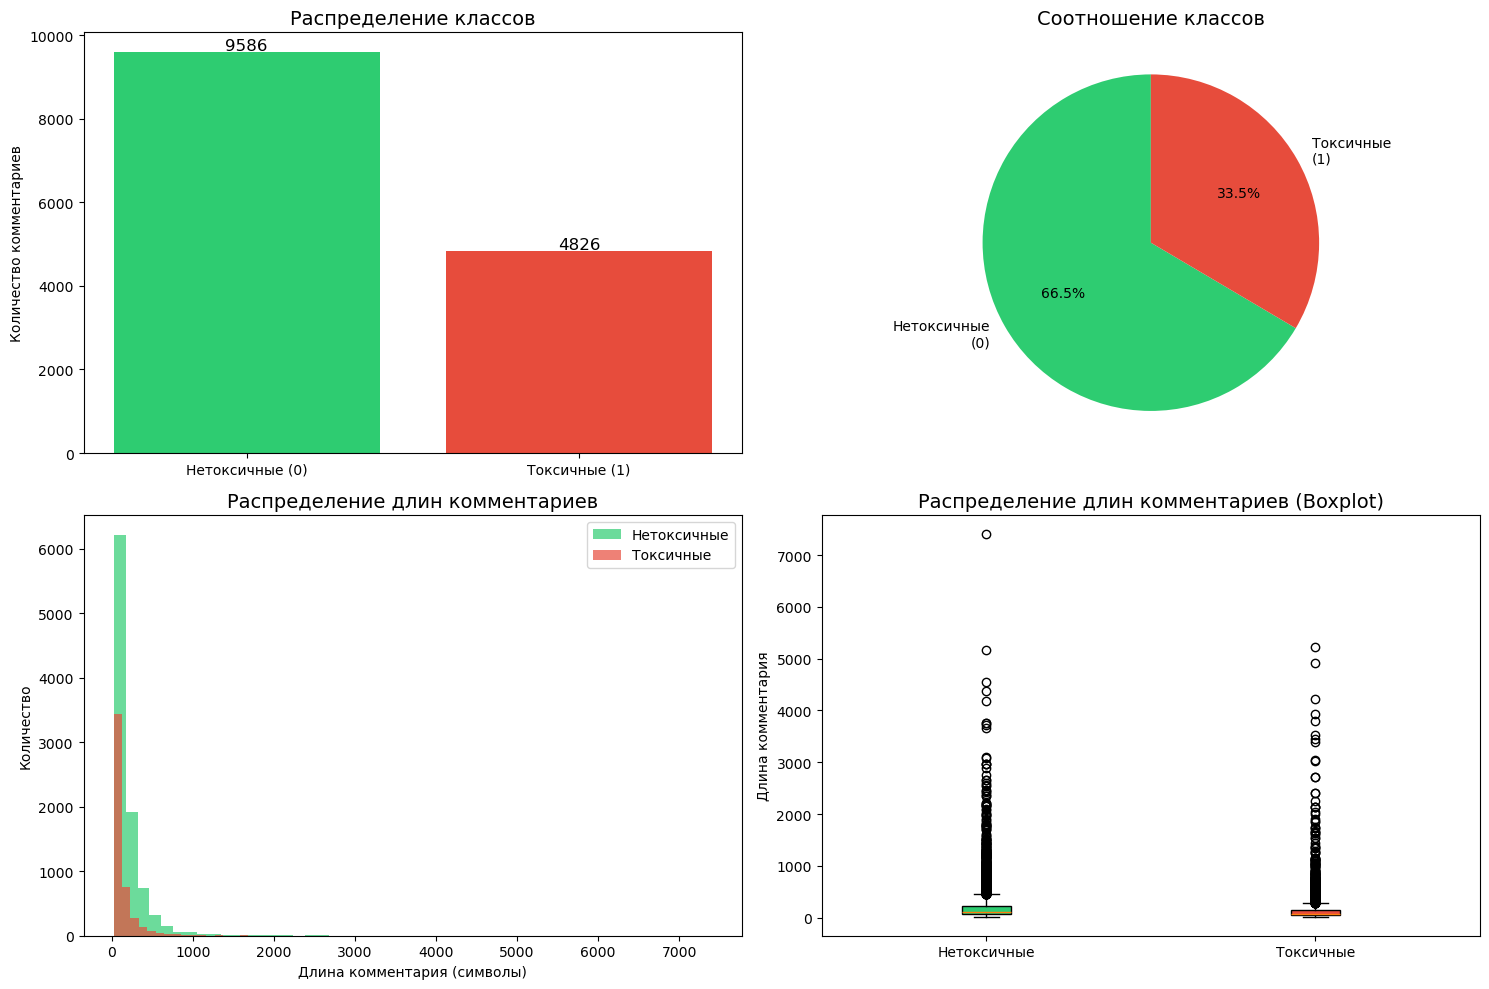


[4/8] Разделение на обучающую и тестовую выборки...
Размер обучающей выборки: 11529
Размер тестовой выборки: 2883

[5/8] Токенизация текстов...
Токенизатор сохранен в 'tokenizer.pickle'

[6/8] Создание и обучение модели...
Веса классов: {0: 0.7517605633802817, 1: 1.493006993006993}
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 300, 300)     15000000    ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 300, 300)    0           ['embedding[0][0]']              
 out1D) 

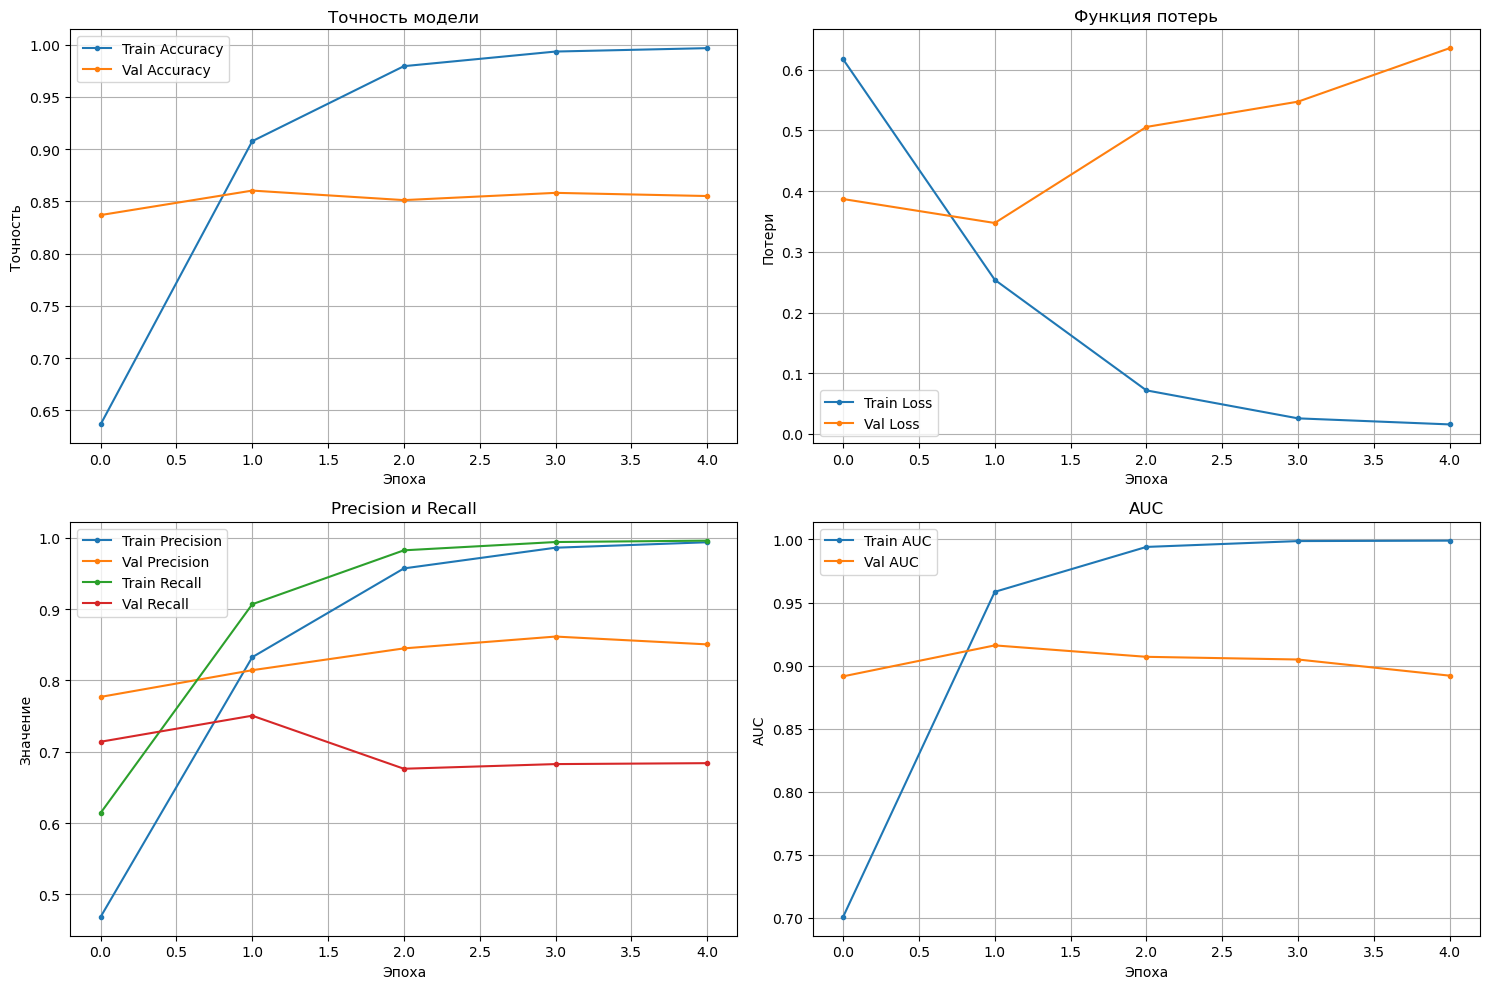


ОТЧЕТ О КЛАССИФИКАЦИИ
                 precision    recall  f1-score   support

Нетоксичный (0)       0.89      0.92      0.90      1918
  Токсичный (1)       0.82      0.76      0.79       965

       accuracy                           0.87      2883
      macro avg       0.85      0.84      0.85      2883
   weighted avg       0.86      0.87      0.86      2883


✅ МОДЕЛЬ СОХРАНЕНА: comment_classifier.h5
Метаданные сохранены в 'model_metadata.pickle'

[8/8] Поиск оптимального порога...
Оптимальный порог: 0.40 (F1-score: 0.8002)

ОБУЧЕНИЕ ЗАВЕРШЕНО!

СОЗДАННЫЕ ФАЙЛЫ:
   1. Модель: comment_classifier_final.keras
   2. Лучшая модель: best_model.keras
   3. Токенизатор: tokenizer.pickle
   4. Метаданные: model_metadata.pickle
   5. Графики: class_distribution.png
   6. Графики: training_history.png
   7. Матрица: confusion_matrix.png


In [8]:
def test_model(model, tokenizer, metadata):
    """
    Тестирование модели на примерах
    """
    print("\n" + "=" * 50)
    print("ТЕСТИРОВАНИЕ МОДЕЛИ")
    print("=" * 50)
    
    test_comments = [
        "это просто замечательно, мне очень понравилось",
        "ужасное качество, никогда не покупайте здесь",
        "нормальный товар, но доставка подвела",
        "ты дурак что ли совсем?",
        "спасибо большое за отличную работу",
        "Верблюдов-то за что? Дебилы, бл..."  # пример из вашего датасета
    ]
    
    for comment in test_comments:
        # Предобработка
        clean = preprocess_text(comment)
        # Токенизация
        seq = tokenizer.texts_to_sequences([clean])
        pad = sequence.pad_sequences(seq, maxlen=metadata['maxlen'])
        # Предсказание
        prob = model.predict(pad, verbose=0)[0][0]
        
        sentiment = "ТОКСИЧНЫЙ" if prob > metadata['threshold'] else "НЕТОКСИЧНЫЙ"
        
        print(f"\nКомментарий: {comment}")
        print(f"Вероятность токсичности: {prob:.4f}")
        print(f"Порог: {metadata['threshold']:.2f}")
        print(f"Результат: {sentiment}")
        
        # Визуализация вероятности
        if prob > metadata['threshold']:
            color = 'red'
            bar_color = 'red'
        else:
            color = 'green'
            bar_color = 'green'
        
        bar_length = int(prob * 50)
        bar = '█' * bar_length + '░' * (50 - bar_length)
        print(f"[{bar}] {prob:.1%}")

if __name__ == "__main__":
    model, tokenizer, metadata = train_model()
    